In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_json('../data/prompts_json/non_benchmark_961.json')
df_benchmark_summary = pd.read_csv('../data/benchmark_summary.csv')
df_cat_delta_detail = pd.read_csv('../data/category_delta_detail.csv')
df_cat_delta_summary = pd.read_csv('../data/category_delta_summary.csv')
df_cat_presence = pd.read_csv('../data/benchmark_category_presence.csv')

In [11]:
df_cat_presence

,qid,source_category,segment,norm_pos,top1_category,top1_adjusted,top1_raw_similarity,top2_category,top2_adjusted,gap,...,raw__Human Nature & Philosophy,adj__Human Nature & Philosophy,"raw__Science, Physics & Math","adj__Science, Physics & Math","raw__Depression, Addiction & Feeling Lost","adj__Depression, Addiction & Feeling Lost",raw__Family Duty & Obligations,adj__Family Duty & Obligations,"raw__Grief, Loss & Death","adj__Grief, Loss & Death"
0,751,"Grief, Loss & Death",thought,1.475410,Family Duty & Obligations,0.042747,0.297300,"Depression, Addiction & Feeling Lost",0.025965,0.016782,...,0.222558,-0.017426,0.230154,0.017225,0.291996,0.025965,0.297300,0.042747,0.268983,0.024042
1,751,"Grief, Loss & Death",thought,1.803279,Family Duty & Obligations,0.001528,0.256082,"Depression, Addiction & Feeling Lost",-0.000425,0.001953,...,0.195054,-0.044930,0.189331,-0.023598,0.265606,-0.000425,0.256082,0.001528,0.229678,-0.015263
2,751,"Grief, Loss & Death",thought,2.131148,Family Duty & Obligations,-0.040568,0.213985,"Depression, Addiction & Feeling Lost",-0.042610,0.002042,...,0.155923,-0.084061,0.148110,-0.064819,0.223421,-0.042610,0.213985,-0.040568,0.187877,-0.057064
3,751,"Grief, Loss & Death",thought,2.459016,"Depression, Addiction & Feeling Lost",-0.049931,0.216100,Family Duty & Obligations,-0.054601,0.004670,...,0.146205,-0.093779,0.135982,-0.076947,0.216100,-0.049931,0.199952,-0.054601,0.177747,-0.067195
4,751,"Grief, Loss & Death",thought,2.786885,"Depression, Addiction & Feeling Lost",-0.047059,0.218972,Family Duty & Obligations,-0.048414,0.001355,...,0.159325,-0.080660,0.149601,-0.063329,0.218972,-0.047059,0.206140,-0.048414,0.195581,-0.049360
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23827,1093,Human Nature & Philosophy,answer,84.821429,"Science, Physics & Math",0.018247,0.227289,Religion & Theology,0.016829,0.001418,...,0.226732,0.011231,0.227289,0.018247,0.219690,-0.026931,0.226928,-0.013363,0.208145,-0.018812
23828,1093,Human Nature & Philosophy,answer,86.607143,"Science, Physics & Math",0.068897,0.277939,Religion & Theology,0.048337,0.020560,...,0.250652,0.035151,0.277939,0.068897,0.243142,-0.003480,0.259663,0.019372,0.239815,0.012857
23829,1093,Human Nature & Philosophy,answer,88.392857,"Science, Physics & Math",0.114716,0.323758,Religion & Theology,0.090102,0.024614,...,0.286699,0.071198,0.323758,0.114716,0.269953,0.023332,0.296206,0.055915,0.278501,0.051543
23830,1093,Human Nature & Philosophy,answer,90.178571,"Science, Physics & Math",0.152720,0.361762,Technology & Definitions,0.116941,0.035779,...,0.307903,0.092401,0.361762,0.152720,0.290072,0.043451,0.325895,0.085605,0.292807,0.065849


In [6]:
sample_df = df.groupby('category', group_keys=False).sample(n=10, random_state=42)
sample_df.to_csv('first_10_sample.csv')

In [6]:
df_benchmark_summary

,qid,own_category,segment,compared_category,similarity,js_divergence,religion_similarity,baseline_similarity,religion_delta
0,929,Applied Ethics & Moral Dilemmas,thought,"Law, Politics, Government & History",0.380626,0.619374,0.381504,0.362259,0.019245
1,929,Applied Ethics & Moral Dilemmas,thought,Technology & Definitions,0.373086,0.626914,0.381504,0.362259,0.019245
2,929,Applied Ethics & Moral Dilemmas,thought,Religion & Theology,0.381504,0.618496,0.381504,0.362259,0.019245
3,929,Applied Ethics & Moral Dilemmas,thought,Applied Ethics & Moral Dilemmas,0.446905,0.553095,0.381504,0.362259,0.019245
4,929,Applied Ethics & Moral Dilemmas,thought,Marriage & Romantic Partnerships,0.501071,0.498929,0.381504,0.362259,0.019245
...,...,...,...,...,...,...,...,...,...
195,845,Marriage & Romantic Partnerships,answer,Human Nature & Philosophy,0.346213,0.653787,0.311537,0.312670,-0.001133
196,845,Marriage & Romantic Partnerships,answer,"Science, Physics & Math",0.299042,0.700958,0.311537,0.312670,-0.001133
197,845,Marriage & Romantic Partnerships,answer,"Depression, Addiction & Feeling Lost",0.524853,0.475147,0.311537,0.312670,-0.001133
198,845,Marriage & Romantic Partnerships,answer,Family Duty & Obligations,0.497218,0.502782,0.311537,0.312670,-0.001133


In [12]:
df_cat_delta_summary

,compared_category,segment,mean,std,count
0,Marriage & Romantic Partnerships,answer,0.087880,0.070745,10
1,Family Duty & Obligations,answer,0.079790,0.065167,10
2,"Depression, Addiction & Feeling Lost",answer,0.069018,0.091330,10
3,"Grief, Loss & Death",answer,0.046393,0.064981,10
4,Applied Ethics & Moral Dilemmas,answer,0.045826,0.050611,10
5,Human Nature & Philosophy,answer,0.039615,0.041957,10
6,Religion & Theology,answer,0.006807,0.027026,10
7,"Science, Physics & Math",answer,0.005648,0.015351,10
8,Technology & Definitions,answer,0.004201,0.011504,10
9,"Law, Politics, Government & History",answer,-0.009849,0.006110,10


In [13]:
df_cat_delta_detail

,qid,own_category,segment,compared_category,similarity,baseline_similarity,category_delta
0,776,Family Duty & Obligations,answer,Applied Ethics & Moral Dilemmas,0.417582,0.299893,0.117689
1,801,Inner Peace & Personal Growth,answer,Applied Ethics & Moral Dilemmas,0.345626,0.286691,0.058935
2,804,Everyday Ethics & Honesty,answer,Applied Ethics & Moral Dilemmas,0.316473,0.320955,-0.004481
3,840,"Depression, Addiction & Feeling Lost",answer,Applied Ethics & Moral Dilemmas,0.319185,0.316375,0.002811
4,845,Marriage & Romantic Partnerships,answer,Applied Ethics & Moral Dilemmas,0.383516,0.312670,0.070846
...,...,...,...,...,...,...,...
195,846,Human Nature & Philosophy,thought,Technology & Definitions,0.324105,0.331364,-0.007259
196,929,Applied Ethics & Moral Dilemmas,thought,Technology & Definitions,0.373086,0.362259,0.010827
197,995,Friendship & Trust,thought,Technology & Definitions,0.306773,0.306855,-0.000082
198,998,Cosmology & Speculative Science,thought,Technology & Definitions,0.284908,0.291159,-0.006251


In [25]:
SURFACE = "#fcfcfb"
TEXT_PRIMARY = "#0b0b0b"
TEXT_SECONDARY = "#52514e"
GRIDLINE = "#e1e0d9"
BASELINE_LINE_COLOR = "#9c9b93"

# Fresh 10-color qualitative palette (matplotlib tab10) -- the project's
# CATEGORY_COLORS reuses 2 hues (Family Duty/Grief), which is fine when
# they're folded into "Other" elsewhere but would clash here since all 10
# categories are on screen simultaneously.
CATEGORY_COLORS = {
    "Religion & Theology":                  "#1f77b4",
    "Law, Politics, Government & History":  "#ff7f0e",
    "Technology & Definitions":              "#2ca02c",
    "Applied Ethics & Moral Dilemmas":       "#d62728",
    "Marriage & Romantic Partnerships":      "#9467bd",
    "Human Nature & Philosophy":             "#8c564b",
    "Science, Physics & Math":               "#e377c2",
    "Depression, Addiction & Feeling Lost":  "#7f7f7f",
    "Family Duty & Obligations":             "#bcbd22",
    "Grief, Loss & Death":                   "#17becf",
}

df = pd.read_csv("../data/category_delta_summary.csv")
piv = df.pivot(index="compared_category", columns="segment", values="mean")

# Average RAW baseline similarity (not delta -- baseline_similarity is the
# thing category_delta already subtracts out) by segment, from the
# per-question benchmark summary. This is on a much larger absolute scale
# (~0.30) than the deltas (~-0.01 to 0.10), since it's raw similarity
# rather than baseline-calibrated signal -- so it gets its own right-hand
# axis rather than squashing the delta lines onto the bottom of the plot.
baseline_avg = (
    df_benchmark_summary.drop_duplicates(subset=["qid", "segment"])
    .groupby("segment")["baseline_similarity"].mean()
)

fig, ax = plt.subplots(figsize=(7, 6.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

x = [0, 1]
for category, row in piv.iterrows():
    color = CATEGORY_COLORS[category]
    y = [row["thought"], row["answer"]]
    ax.plot(x, y, color=color, linewidth=2, marker="o", markersize=7,
             label=category, zorder=2)

ax.axhline(0, color=TEXT_SECONDARY, linewidth=1, linestyle="--", zorder=0)
ax.set_xticks(x)
ax.set_xticklabels(["Thought", "Answer"], fontsize=10, color=TEXT_PRIMARY)
ax.set_xlim(-0.2, 1.2)
ax.set_ylabel("Category delta  (similarity to category − avg. similarity to baseline categories)",
              color=TEXT_SECONDARY, fontsize=9)
ax.set_title("Category delta: thought → answer (benchmark pilot, n=10)",
             color=TEXT_PRIMARY, fontsize=11.5, loc="left")
ax.grid(True, color=GRIDLINE, linewidth=0.8, axis="y", zorder=0)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(GRIDLINE)
ax.tick_params(colors=TEXT_SECONDARY, labelsize=8)

# Secondary axis: average raw baseline similarity, thought vs answer.
ax2 = ax.twinx()
ax2.plot(x, [baseline_avg["thought"], baseline_avg["answer"]],
          color=BASELINE_LINE_COLOR, linewidth=2, linestyle="--", marker="s",
          markersize=6, zorder=2, label="Avg. baseline similarity (raw, right axis)")
ax2.set_ylabel("Avg. baseline similarity (raw)", color=TEXT_SECONDARY, fontsize=9)
ax2.spines[["top", "left"]].set_visible(False)
ax2.spines["right"].set_color(GRIDLINE)
ax2.tick_params(colors=TEXT_SECONDARY, labelsize=8)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, frameon=False, fontsize=8,
          labelcolor=TEXT_PRIMARY, loc="center left", bbox_to_anchor=(1.15, 0.5))

fig.tight_layout()
fig.savefig("../imagescategory_delta_slope.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.close(fig)
print("Wrote category_delta_slope.png")
print(baseline_avg)

Wrote category_delta_slope.png
segment
answer     0.308910
thought    0.324201
Name: baseline_similarity, dtype: float64


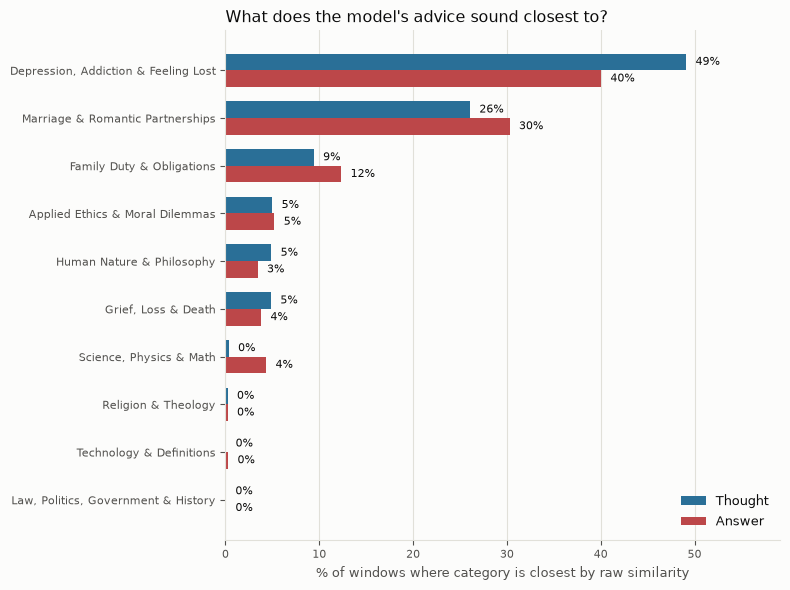

segment                               answer  thought
raw_top1                                             
Depression, Addiction & Feeling Lost    40.0     49.1
Marriage & Romantic Partnerships        30.3     26.1
Family Duty & Obligations               12.3      9.4
Applied Ethics & Moral Dilemmas          5.2      5.0
Grief, Loss & Death                      3.8      4.9
Human Nature & Philosophy                3.4      4.9
Science, Physics & Math                  4.3      0.3
Religion & Theology                      0.2      0.2
Technology & Definitions                 0.3      0.1
Law, Politics, Government & History      0.1      0.1


In [29]:
# Which category does a window look closest to on RAW similarity alone (no
# baseline correction)? This is the "attractor" pattern from
# benchmark_category_presence.py's docstring: personal-advice-style benchmark
# questions tend to land closest to a couple of categories regardless of
# their actual topic, rather than spreading evenly across all 10.
raw_cols = [c for c in df_cat_presence.columns if c.startswith("raw__")]
df_cat_presence["raw_top1"] = (
    df_cat_presence[raw_cols].idxmax(axis=1).str.replace("raw__", "", regex=False)
)

# Share of windows (not raw counts) per segment, since thought and answer
# segments have very different total window counts and raw counts wouldn't
# be comparable side by side.
counts = df_cat_presence.groupby(["raw_top1", "segment"]).size().unstack("segment", fill_value=0)
pct_values = (counts.div(counts.sum(axis=0), axis=1) * 100).sort_values("thought")

def side_bar_plot(pct, x_label):
    THOUGHT_COLOR = "#2a6f97"
    ANSWER_COLOR = "#bc4749"

    fig, ax = plt.subplots(figsize=(8, 6), facecolor=SURFACE)
    ax.set_facecolor(SURFACE)

    y = range(len(pct))
    bar_h = 0.35
    ax.barh([i + bar_h / 2 for i in y], pct["thought"], height=bar_h, color=THOUGHT_COLOR, label="Thought", zorder=2)
    ax.barh([i - bar_h / 2 for i in y], pct["answer"], height=bar_h, color=ANSWER_COLOR, label="Answer", zorder=2)

    for i, (t_val, a_val) in enumerate(zip(pct["thought"], pct["answer"])):
        ax.text(t_val + 1, i + bar_h / 2, f"{t_val:.0f}%", va="center", fontsize=8, color=TEXT_PRIMARY)
        ax.text(a_val + 1, i - bar_h / 2, f"{a_val:.0f}%", va="center", fontsize=8, color=TEXT_PRIMARY)

    ax.set_yticks(list(y))
    ax.set_yticklabels(pct.index, fontsize=9, color=TEXT_PRIMARY)
    ax.set_xlim(0, pct.to_numpy().max() + 10)
    ax.set_xlabel(x_label,
                color=TEXT_SECONDARY, fontsize=9)
    ax.set_title("What does the model's advice sound closest to?",
                color=TEXT_PRIMARY, fontsize=11.5, loc="left")
    ax.grid(True, color=GRIDLINE, linewidth=0.8, axis="x", zorder=0)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(GRIDLINE)
    ax.tick_params(colors=TEXT_SECONDARY, labelsize=8)
    ax.legend(frameon=False, fontsize=9, labelcolor=TEXT_PRIMARY, loc="lower right")

    fig.tight_layout()
    fig.savefig("../images/raw_top1_category_share.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
    plt.show()
    print(pct.round(1).sort_values("thought", ascending=False))

side_bar_plot(pct_values, "% of windows where category is closest by raw similarity")

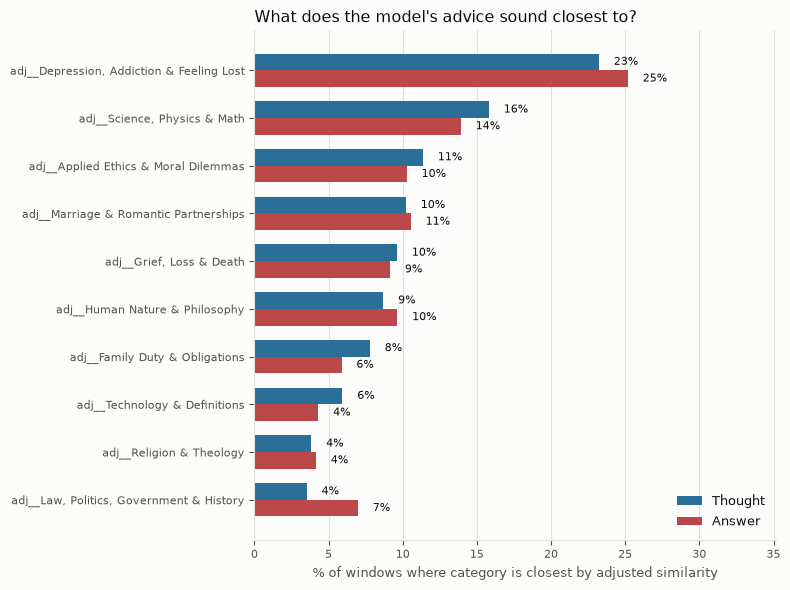

segment                                    answer  thought
adj_top1                                                  
adj__Depression, Addiction & Feeling Lost    25.2     23.2
adj__Science, Physics & Math                 13.9     15.8
adj__Applied Ethics & Moral Dilemmas         10.3     11.4
adj__Marriage & Romantic Partnerships        10.5     10.2
adj__Grief, Loss & Death                      9.1      9.6
adj__Human Nature & Philosophy                9.6      8.7
adj__Family Duty & Obligations                5.9      7.8
adj__Technology & Definitions                 4.3      5.9
adj__Religion & Theology                      4.1      3.8
adj__Law, Politics, Government & History      7.0      3.5


In [30]:
adj_values = [c for c in df_cat_presence.columns if c.startswith("adj__")]
df_cat_presence["adj_top1"] = (
    df_cat_presence[adj_values].idxmax(axis=1).str.replace("raw__", "", regex=False)
)

# Share of windows (not raw counts) per segment, since thought and answer
# segments have very different total window counts and raw counts wouldn't
# be comparable side by side.
counts = df_cat_presence.groupby(["adj_top1", "segment"]).size().unstack("segment", fill_value=0)
pct_values_adj = (counts.div(counts.sum(axis=0), axis=1) * 100).sort_values("thought")

side_bar_plot(pct_values_adj, "% of windows where category is closest by adjusted similarity")

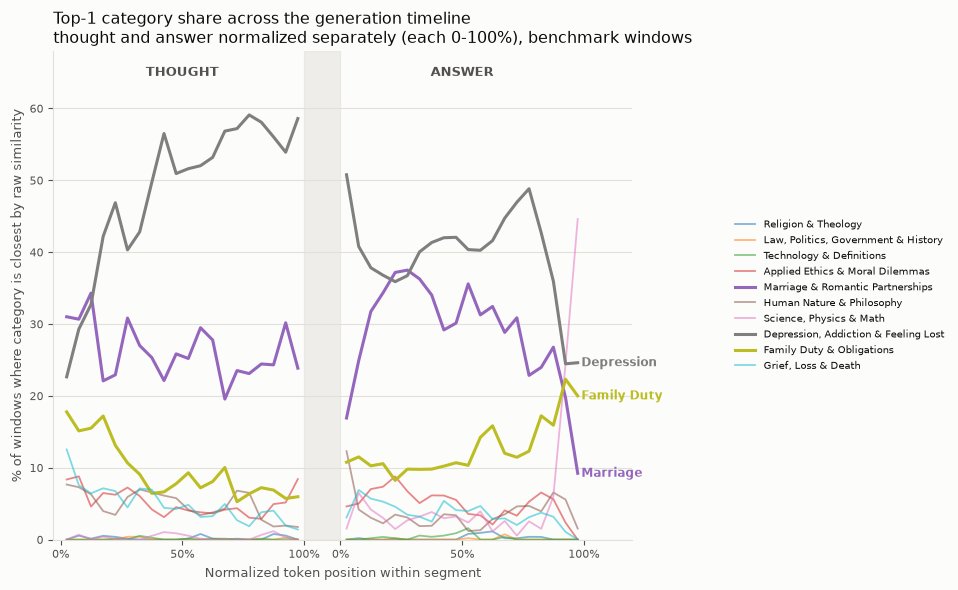

In [31]:
import numpy as np

# Same top1_category values as the bar plots above, but keeping the
# normalized-position axis (norm_pos) instead of collapsing it, binned so
# each point is a stable percentage rather than a single noisy window.
# Thought and answer are normalized separately (each own 0-100%) and drawn
# side by side rather than merged into one scale, since thought:answer
# length ratios vary per question and merging would blur where one segment
# ends and the other begins.
BIN_COUNT = 20
GAP = 15
bin_edges = np.linspace(0, 100, BIN_COUNT + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

TOP_CATEGORIES = {"Depression, Addiction & Feeling Lost", "Marriage & Romantic Partnerships", "Family Duty & Obligations"}

def timeline_plot(top1_col, x_label, filename):
    df_cat_presence["pos_bin"] = pd.cut(df_cat_presence["norm_pos"], bins=bin_edges, labels=False, include_lowest=True)

    def segment_timeline(segment):
        sub = df_cat_presence[df_cat_presence["segment"] == segment]
        counts = sub.groupby(["pos_bin", top1_col]).size().unstack(top1_col, fill_value=0)
        counts = counts.reindex(index=range(BIN_COUNT), columns=list(CATEGORY_COLORS), fill_value=0)
        return counts.div(counts.sum(axis=1), axis=0) * 100

    thought_pct = segment_timeline("thought")
    answer_pct = segment_timeline("answer")

    x_thought = bin_centers
    x_answer = 100 + GAP + bin_centers

    fig, ax = plt.subplots(figsize=(10, 6), facecolor=SURFACE)
    ax.set_facecolor(SURFACE)

    for category, color in CATEGORY_COLORS.items():
        lw = 2.2 if category in TOP_CATEGORIES else 1.3
        alpha = 1.0 if category in TOP_CATEGORIES else 0.55
        ax.plot(x_thought, thought_pct[category], color=color, linewidth=lw, alpha=alpha, zorder=3)
        ax.plot(x_answer, answer_pct[category], color=color, linewidth=lw, alpha=alpha, zorder=3, label=category)
        if category in TOP_CATEGORIES:
            ax.text(x_answer[-1] + 1.5, answer_pct[category].iloc[-1], category.split(",")[0].split("&")[0].strip(),
                     color=color, fontsize=8.5, va="center", fontweight="bold")

    ax.axvspan(100, 100 + GAP, color=GRIDLINE, alpha=0.5, zorder=1)

    ymax = max(thought_pct.to_numpy().max(), answer_pct.to_numpy().max()) * 1.15
    ax.set_ylim(0, ymax)
    ax.text(50, ymax * 0.97, "THOUGHT", ha="center", va="top", fontsize=9.5, color=TEXT_SECONDARY, fontweight="bold")
    ax.text(100 + GAP + 50, ymax * 0.97, "ANSWER", ha="center", va="top", fontsize=9.5, color=TEXT_SECONDARY, fontweight="bold")

    ax.set_xticks([0, 50, 100, 100 + GAP, 100 + GAP + 50, 100 + GAP + 100])
    ax.set_xticklabels(["0%", "50%", "100%", "0%", "50%", "100%"], fontsize=8, color=TEXT_SECONDARY)
    ax.set_xlabel("Normalized token position within segment", color=TEXT_SECONDARY, fontsize=9)
    ax.set_ylabel(x_label, color=TEXT_SECONDARY, fontsize=9)
    ax.set_title("Top-1 category share across the generation timeline\nthought and answer normalized separately (each 0-100%), benchmark windows",
                 color=TEXT_PRIMARY, fontsize=11.5, loc="left")

    ax.grid(True, color=GRIDLINE, linewidth=0.8, axis="y", zorder=0)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(GRIDLINE)
    ax.tick_params(colors=TEXT_SECONDARY, labelsize=8)
    ax.set_xlim(-3, 100 + GAP + 100 + 20)
    ax.legend(frameon=False, fontsize=7.5, labelcolor=TEXT_PRIMARY, loc="center left", bbox_to_anchor=(1.16, 0.5))

    fig.tight_layout()
    fig.savefig(f"../images/{filename}", dpi=150, facecolor=SURFACE, bbox_inches="tight")
    plt.show()

# NOTE: bin 0 and bin 19 (the very edges of each segment) are built from far
# fewer windows (~65) than the interior bins (~500-550) -- a window only
# lands at the extreme edge if its question's segment is long enough to
# center a 10-token window there, so short answers/thoughts don't
# contribute to the edges. Treat spikes confined to just the first/last
# bin as possible small-sample noise, not signal, until checked against a
# larger benchmark.
timeline_plot("raw_top1", "% of windows where category is closest by raw similarity", "raw_top1_timeline.png")

ValueError: Axis limits cannot be NaN or Inf

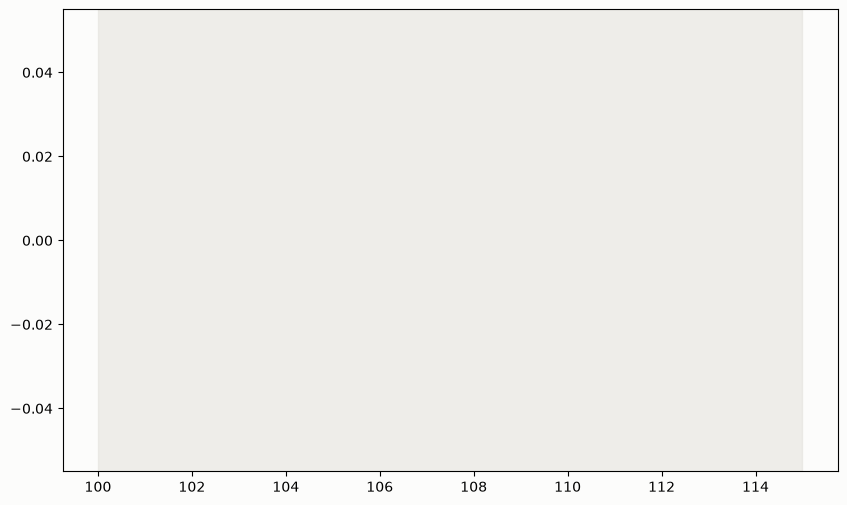

In [32]:
timeline_plot('adj_top1', "% of windows where category is closest by adjusted similarity", "adj_top1_timeline.png")